# Models Benshmarks

In [1]:
# Downloading totto dataset from the official Google bucket
!wget -q https://storage.googleapis.com/totto-public/totto_data.zip
!unzip -q totto_data.zip
!ls totto_data/

'wget' is not recognized as an internal or external command,
operable program or batch file.


'unzip' is not recognized as an internal or external command,
operable program or batch file.
'ls' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
!pip install -q transformers accelerate bitsandbytes sentencepiece
!pip install -q evaluate rouge_score bert_score nltk sacrebleu

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.0 MB/s eta 0:00:00


In [ ]:
# Loading validation sample
from datasets import Dataset
import json, random

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

val_data = load_jsonl("totto_data/totto_dev_data.jsonl")

random.seed(42)
sample = random.sample(val_data, 300)

# Extract references (final_sentence from annotations)
references = [
    ex["sentence_annotations"][0]["final_sentence"]
    for ex in sample
]

In [ ]:
# Building the prompt from table
def table_to_text(example):
    """
    Build a rich, structured prompt from highlighted cells.
    Includes: page/section title, column headers, row headers,
    and each highlighted cell value with its positional context.
    """
    page_title    = example.get("table_page_title", "").strip()
    section_title = example.get("table_section_title", "").strip()
    section_text  = example.get("table_section_text", "").strip()
    table         = example["table"]
    highlighted   = example["highlighted_cells"]

    # --- Extract header row (row 0, is_header=True cells) ---
    headers = []
    if table:
        for cell in table[0]:
            if cell.get("is_header"):
                headers.append(cell["value"].strip())

    # --- Extract highlighted cells with context ---
    cell_descriptions = []
    for row_idx, col_idx in highlighted:
        try:
            cell = table[row_idx][col_idx]
        except IndexError:
            continue

        value = cell["value"].strip()
        if not value:
            continue

        # Get column header for this cell
        col_header = ""
        if table and table[0] and col_idx < len(table[0]):
            col_header = table[0][col_idx]["value"].strip()

        # Get row header (first cell of the row, if it's a header)
        row_header = ""
        if table[row_idx] and table[row_idx][0].get("is_header"):
            row_header = table[row_idx][0]["value"].strip()

        # Build contextual description of the cell
        if col_header and row_header and col_header != row_header:
            cell_descriptions.append(f"{row_header} / {col_header}: {value}")
        elif col_header:
            cell_descriptions.append(f"{col_header}: {value}")
        elif row_header:
            cell_descriptions.append(f"{row_header}: {value}")
        else:
            cell_descriptions.append(value)

    # --- Assemble prompt ---
    context_parts = []
    if page_title:
        context_parts.append(f"Topic: {page_title}")
    if section_title and section_title != page_title:
        context_parts.append(f"Section: {section_title}")
    if section_text:
        context_parts.append(f"Context: {section_text[:120]}")  # cap to avoid token overflow
    if headers:
        context_parts.append(f"Table columns: {' | '.join(headers)}")

    cells_str = "; ".join(cell_descriptions)
    context_str = ". ".join(context_parts)

    prompt = (
        f"{context_str}. "
        f"Highlighted data: {cells_str}. "
        f"Write one sentence summarizing this information:"
    )
    return prompt

prompts = [table_to_text(ex) for ex in sample]

print(prompts[0])

Topic: Nonmetal. Section: Metalloid. Context: The seven metalloids are boron (B), silicon (Si), germanium (Ge), arsenic (As), antimony (Sb), tellurium (Te), and astat. Table columns: Electronegativity values of metalloids and nonmetals. Highlighted data: Br 2.96. Write one sentence summarizing this information:


In [ ]:
import evaluate
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

rouge  = evaluate.load("rouge")
meteor = evaluate.load("meteor")

# BERTScore: use a lightweight model to avoid OOM between benchmark runs
# deberta-xlarge-mnli is too heavy; distilbert is fast and sufficient for ranking
import bert_score as bs

def compute_all_metrics(predictions, references, samples):
    """
    Compute ROUGE-L, METEOR, BERTScore F1, and PARENT.
    Returns a dict of average scores.
    """
    from collections import Counter
    import re

    # --- ROUGE-L ---
    rouge_result = rouge.compute(
        predictions=predictions,
        references=references,
        rouge_types=["rougeL"]
    )
    rougeL = round(rouge_result["rougeL"], 4)

    # --- METEOR ---
    meteor_result = meteor.compute(
        predictions=predictions,
        references=references
    )
    meteor_score = round(meteor_result["meteor"], 4)

    # --- BERTScore ---
    P, R, F1 = bs.score(
        predictions,
        references,
        lang="en",
        model_type="distilbert-base-uncased",
        verbose=False,
        device="cuda"
    )
    bertscore_f1 = round(F1.mean().item(), 4)

    # --- PARENT (table-faithful F1) ---
    def tokenize(text):
        return re.findall(r'\w+', text.lower())

    def token_f1(pred_tokens, ref_tokens):
        pred_c = Counter(pred_tokens)
        ref_c  = Counter(ref_tokens)
        common = sum((pred_c & ref_c).values())
        if common == 0:
            return 0.0
        p = common / sum(pred_c.values())
        r = common / sum(ref_c.values())
        return 2 * p * r / (p + r)

    parent_scores = []
    for pred, ref, ex in zip(predictions, references, samples):
        table = ex["table"]
        highlighted = ex["highlighted_cells"]
        table_tokens = []
        for row_idx, col_idx in highlighted:
            try:
                table_tokens += tokenize(table[row_idx][col_idx]["value"])
            except IndexError:
                continue

        pred_tokens  = tokenize(pred)
        ref_tokens   = tokenize(ref)
        f1_ref       = token_f1(pred_tokens, ref_tokens)
        f1_table     = token_f1(pred_tokens, table_tokens) if table_tokens else 0.0
        parent_scores.append(0.5 * f1_ref + 0.5 * f1_table)

    parent = round(sum(parent_scores) / len(parent_scores), 4)

    return {
        "ROUGE-L":   rougeL,
        "METEOR":    meteor_score,
        "BERTScore": bertscore_f1,
        "PARENT":    parent
    }

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForCausalLM

def run_inference(model, tokenizer, prompts, batch_size=8, max_new_tokens=64, is_causal=False):
    model.eval()
    predictions = []

    for i in range(0, len(prompts), batch_size):
        batch = prompts[i:i+batch_size]
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        ).to(model.device)

        with torch.no_grad():
            if is_causal:
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    pad_token_id=tokenizer.eos_token_id
                )
                # Strip prompt from causal output
                decoded = [
                    tokenizer.decode(
                        out[inputs["input_ids"].shape[1]:],
                        skip_special_tokens=True
                    )
                    for out in outputs
                ]
            else:
                outputs = model.generate(**inputs, max_new_tokens=max_new_tokens)
                decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)

        predictions.extend(decoded)
        print(f"  Batch {i//batch_size + 1} done", end="\r")

    return predictions

In [ ]:
from transformers import BitsAndBytesConfig
import torch

results = {}

models_to_test = [
    ("FLAN-T5 Small", "google/flan-t5-small", False),
    ("FLAN-T5 Base",  "google/flan-t5-base",  False),
    ("mT5 Small",     "google/mt5-small",      False),
    #("Llama 2 7B",    "meta-llama/Llama-2-7b-hf", True),
]

for name, model_id, is_causal in models_to_test:
    print(f"\n{'='*40}\nRunning: {name}\n{'='*40}")
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_id)

        if is_causal:
            bnb_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_compute_dtype=torch.float16,
                bnb_4bit_use_double_quant=True,
            )
            model = AutoModelForCausalLM.from_pretrained(
                model_id,
                quantization_config=bnb_config,
                device_map="auto",
                token="YOUR_HF_TOKEN"
            )
        else:
            model = AutoModelForSeq2SeqLM.from_pretrained(
                model_id,
                torch_dtype=torch.float16,
                device_map="auto"
            )

        preds  = run_inference(model, tokenizer, prompts, is_causal=is_causal)
        scores = compute_all_metrics(preds, references, sample)

        results[name] = {**scores, "sample_pred": preds[0]}

        print(f"  ROUGE-L  : {scores['ROUGE-L']}")
        print(f"  METEOR   : {scores['METEOR']}")
        print(f"  BERTScore: {scores['BERTScore']}")
        print(f"  PARENT   : {scores['PARENT']}")

    except Exception as e:
        results[name] = {"error": str(e)}
        print(f"Failed: {e}")

    del model
    torch.cuda.empty_cache()


Running: FLAN-T5 Small


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ROUGE-L  : 0.0051
  METEOR   : 0.0344
  BERTScore: 0.5668
  PARENT   : 0.0006


In [ ]:
import pandas as pd

rows = []
for model_name, res in results.items():
    if "error" in res:
        rows.append({"Model": model_name, "ROUGE-L": "—", "METEOR": "—",
                     "BERTScore": "—", "PARENT": "—", "Note": res["error"][:60]})
    else:
        rows.append({
            "Model":     model_name,
            "ROUGE-L":   res.get("ROUGE-L"),
            "METEOR":    res.get("METEOR"),
            "BERTScore": res.get("BERTScore"),
            "PARENT":    res.get("PARENT"),
        })

df = pd.DataFrame(rows)

# Composite score: equal-weighted average of all four metrics
# (mT5 PARENT anomaly won't drag BERTScore, so this is fairer)
numeric_cols = ["ROUGE-L", "METEOR", "BERTScore", "PARENT"]
df["Composite"] = df[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
).mean(axis=1).round(4)

df = df.sort_values("Composite", ascending=False)
print(df.to_string(index=False))

        Model  ROUGE-L  METEOR  BERTScore  PARENT  Composite
 FLAN-T5 Base   0.3682  0.3744     0.8122  0.3746     0.4824
FLAN-T5 Small   0.3239  0.3293     0.7875  0.3320     0.4432
    mT5 Small   0.0051  0.0344     0.5668  0.0006     0.1517


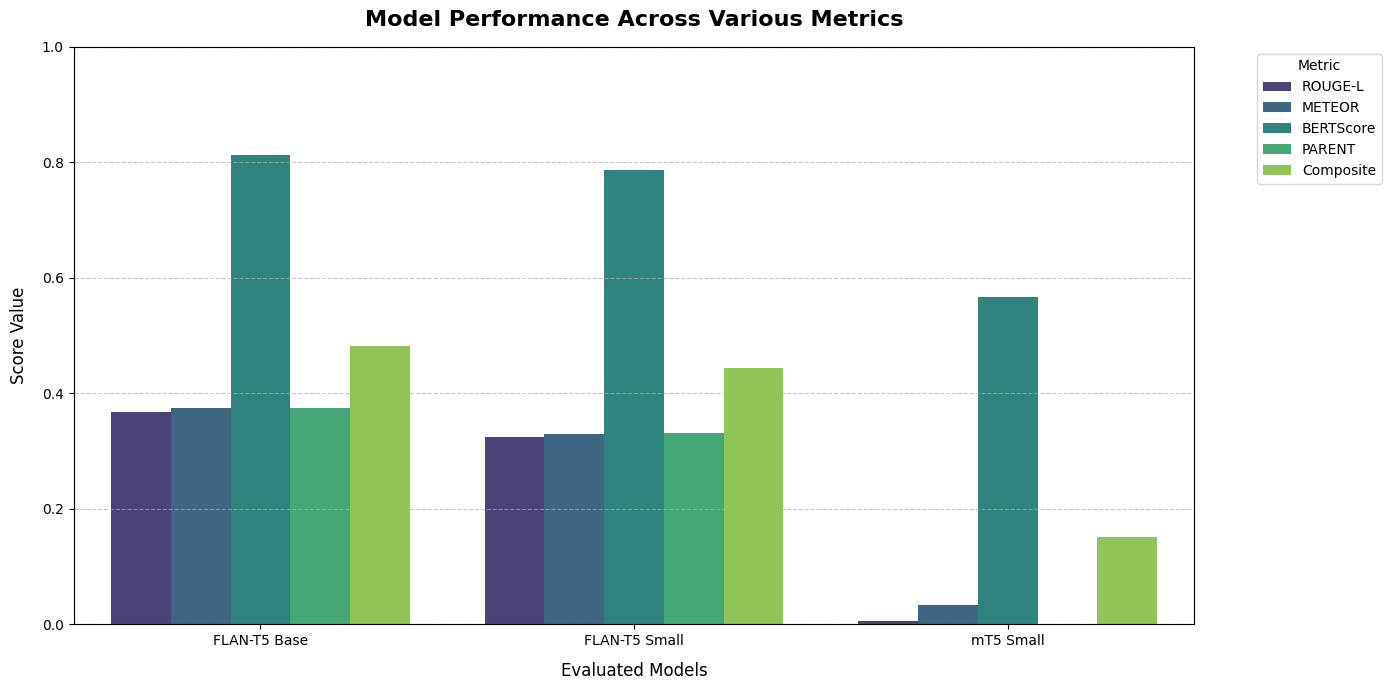

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df is available. If the kernel was reset, df might need to be recreated
# from 'rows' if kQ62xbOb6eXJ was not re-executed.
# For this fix, we assume df is available from the previous execution of kQ62xbOb6eXJ

# Melt the DataFrame to long format for grouped bar plot
df_melted = df.melt(id_vars=['Model'],
                    value_vars=['ROUGE-L', 'METEOR', 'BERTScore', 'PARENT', 'Composite'],
                    var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='viridis')

plt.title('Model Performance Across Various Metrics', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Evaluated Models', fontsize=12, labelpad=10)
plt.ylabel('Score Value', fontsize=12, labelpad=10)
plt.ylim(0, 1.0) # Scores are typically between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()